# IE406 - Machine Learning: Lab-1
## Linear Regression using Mini-Batch Gradient Descent

**Course Instructor:** Prof. Arunava Chakravarty  
**Teaching Assistants:** Hetul Kadiya, Kathan Shah  

---

### Objectives:
- Implement Linear Regression using Mini-Batch Gradient Descent completely from scratch using **NumPy**.
- Understand the effect of **learning rate**, **batch size**, and **feature normalization** on model convergence.
- Evaluate the performance of the learned model on unseen test data.
- Visualize the prediction performance and loss curves of the model.

### Setup and Environment Initialization

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Set random seed for full reproducibility
np.random.seed(42)

# Global plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Task 1: Dataset Preparation

1. Load the **California Housing Dataset** using `fetch_california_housing()`.
2. Split the dataset into:
   - **Training Set (60%)**
   - **Validation Set (20%)**
   - **Test Set (20%)**
3. Standardize all input features using **only the statistics ($\mu, \sigma$) computed from the training set**.

In [2]:
# 1. Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
X_raw = housing.data.values
y_raw = housing.target.values
feature_names = housing.feature_names

print("=" * 65)
print("1. DATASET LOADED SUCCESSFULLY")
print("=" * 65)
print(f"Total Samples: {X_raw.shape[0]}, Input Features: {X_raw.shape[1]}")
print(f"Feature Names: {list(feature_names)}")

# 2. Split dataset: 60% Train, 20% Validation, 20% Test
# Step A: 80% Temp (Train+Val), 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42
)

# Step B: Split 80% Temp into 75% Train (60% of total) and 25% Validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

n_total = len(X_raw)
print("\n" + "=" * 65)
print("2. DATASET SPLIT SUMMARY")
print("=" * 65)
print(f"Training Set:   {X_train.shape[0]:>6} samples ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]:>6} samples ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test Set:       {X_test.shape[0]:>6} samples ({X_test.shape[0]/n_total*100:.1f}%)")

# 3. Standardize input features using ONLY statistics from the training set
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)
std_train_safe = np.where(std_train == 0, 1.0, std_train)

X_train_scaled = (X_train - mean_train) / std_train_safe
X_val_scaled = (X_val - mean_train) / std_train_safe
X_test_scaled = (X_test - mean_train) / std_train_safe

print("\n" + "=" * 65)
print("3. FEATURE STANDARDIZATION SANITY CHECK")
print("=" * 65)
df_stats = pd.DataFrame({
    'Feature': feature_names,
    'Train Mean (Raw)': mean_train.round(3),
    'Train Std (Raw)': std_train.round(3),
    'Scaled Mean': np.mean(X_train_scaled, axis=0).round(4),
    'Scaled Std': np.std(X_train_scaled, axis=0).round(4)
})
print(df_stats.to_string(index=False))

1. DATASET LOADED SUCCESSFULLY
Total Samples: 20640, Input Features: 8
Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

2. DATASET SPLIT SUMMARY
Training Set:    12384 samples (60.0%)
Validation Set:   4128 samples (20.0%)
Test Set:         4128 samples (20.0%)

3. FEATURE STANDARDIZATION SANITY CHECK
   Feature  Train Mean (Raw)  Train Std (Raw)  Scaled Mean  Scaled Std
    MedInc             3.870            1.888         -0.0         1.0
  HouseAge            28.586           12.608          0.0         1.0
  AveRooms             5.412            2.077          0.0         1.0
 AveBedrms             1.093            0.362         -0.0         1.0
Population          1427.290         1140.933          0.0         1.0
  AveOccup             3.033            7.074         -0.0         1.0
  Latitude            35.642            2.131          0.0         1.0
 Longitude          -119.580            2.005         -0.0     

---
## Task 2: Implement Mini-Batch Gradient Descent

We implement Linear Regression using Mini-Batch Gradient Descent completely from scratch using **NumPy**.

### Mathematical Formulation:
1. **Model Hypothesis**:
   $$\hat{y} = X \mathbf{w} + b = X_b \mathbf{w}_b$$
   where $X_b = [X, \mathbf{1}]$ includes a bias column of 1s, and $\mathbf{w}_b = [\mathbf{w}, b]^T$ contains weights and bias.

2. **Mean Squared Error (MSE) Loss Function**:
   $$J(\mathbf{w}_b) = \frac{1}{2 N_{batch}} \sum_{i=1}^{N_{batch}} (\hat{y}_i - y_i)^2 = \frac{1}{2 N_{batch}} \| X_{batch} \mathbf{w}_b - \mathbf{y}_{batch} \|^2$$

3. **Gradient Calculation**:
   $$\nabla_{\mathbf{w}_b} J = \frac{1}{N_{batch}} X_{batch}^T (X_{batch} \mathbf{w}_b - \mathbf{y}_{batch})$$

4. **Weight Update Rule**:
   $$\mathbf{w}_b \leftarrow \mathbf{w}_b - \alpha \nabla_{\mathbf{w}_b} J$$
   where $\alpha$ is the learning rate.

In [3]:
class LinearRegressionMBGD:
    """
    Linear Regression model trained using Mini-Batch Gradient Descent from scratch.
    """
    def __init__(self, learning_rate=0.01, batch_size=128, epochs=100, tolerance=1e-7):
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.train_loss_history = []
        self.val_loss_history = []
        self.epochs_run = 0
        self.training_time = 0.0

    @staticmethod
    def _add_bias(X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    @staticmethod
    def compute_mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        
        # Add bias feature (column of 1s)
        X_tr_b = self._add_bias(X_train)
        if X_val is not None:
            X_v_b = self._add_bias(X_val)
        
        n_samples, n_features = X_tr_b.shape
        
        # Initialize weights to zeros
        self.weights = np.zeros(n_features)
        
        self.train_loss_history = []
        self.val_loss_history = []
        
        # Determine actual batch size
        effective_batch_size = n_samples if (self.batch_size is None or self.batch_size >= n_samples) else self.batch_size
        
        for epoch in range(self.epochs):
            # Shuffle training data at start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_tr_b[indices]
            y_shuffled = y_train[indices]
            
            diverged = False
            # Mini-batch gradient updates
            for i in range(0, n_samples, effective_batch_size):
                X_batch = X_shuffled[i:i + effective_batch_size]
                y_batch = y_shuffled[i:i + effective_batch_size]
                
                # Forward pass
                y_pred_batch = np.dot(X_batch, self.weights)
                
                # Gradient calculation
                error = y_pred_batch - y_batch
                gradient = np.dot(X_batch.T, error) / len(y_batch)
                
                # Weight update
                self.weights -= self.learning_rate * gradient
                
                # Check for divergence / overflow
                if np.isnan(self.weights).any() or np.isinf(self.weights).any() or np.abs(self.weights).max() > 1e10:
                    diverged = True
                    break

            if diverged:
                self.train_loss_history.append(float('nan'))
                if X_val is not None:
                    self.val_loss_history.append(float('nan'))
                self.epochs_run = epoch + 1
                self.training_time = time.time() - start_time
                return self

            # Record epoch losses (Standard MSE)
            y_train_pred = np.dot(X_tr_b, self.weights)
            train_mse = self.compute_mse(y_train, y_train_pred)
            self.train_loss_history.append(train_mse)
            
            if X_val is not None:
                y_val_pred = np.dot(X_v_b, self.weights)
                val_mse = self.compute_mse(y_val, y_val_pred)
                self.val_loss_history.append(val_mse)

            # Convergence check
            if epoch > 5 and abs(self.train_loss_history[-2] - self.train_loss_history[-1]) < self.tolerance:
                self.epochs_run = epoch + 1
                break
        else:
            self.epochs_run = self.epochs
            
        self.training_time = time.time() - start_time
        return self

    def predict(self, X):
        X_b = self._add_bias(X)
        return np.dot(X_b, self.weights)

print("LinearRegressionMBGD class defined successfully.")

LinearRegressionMBGD class defined successfully.


---
## Task 3: Effect of Learning Rate

Train the model using the following learning rates:
$$\eta \in [10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10]$$
- **Batch Size:** 128
- **Epochs:** 100

TASK 3: LEARNING RATE PERFORMANCE SUMMARY
 Learning Rate Final Train Loss (MSE) Final Val Loss (MSE)  Epochs Run    Status
       0.00001                4.72093              4.81275         100 Converged
       0.00010                1.34678              1.36796         100 Converged
       0.00100                0.54329              0.55480         100 Converged
       0.01000                0.51443              0.52982         100 Converged
       0.10000     Diverged (NaN/Inf)   Diverged (NaN/Inf)          11  Diverged
       1.00000     Diverged (NaN/Inf)   Diverged (NaN/Inf)           5  Diverged
      10.00000     Diverged (NaN/Inf)   Diverged (NaN/Inf)           1  Diverged

---> BEST LEARNING RATE: 0.01 (Validation MSE = 0.52982)


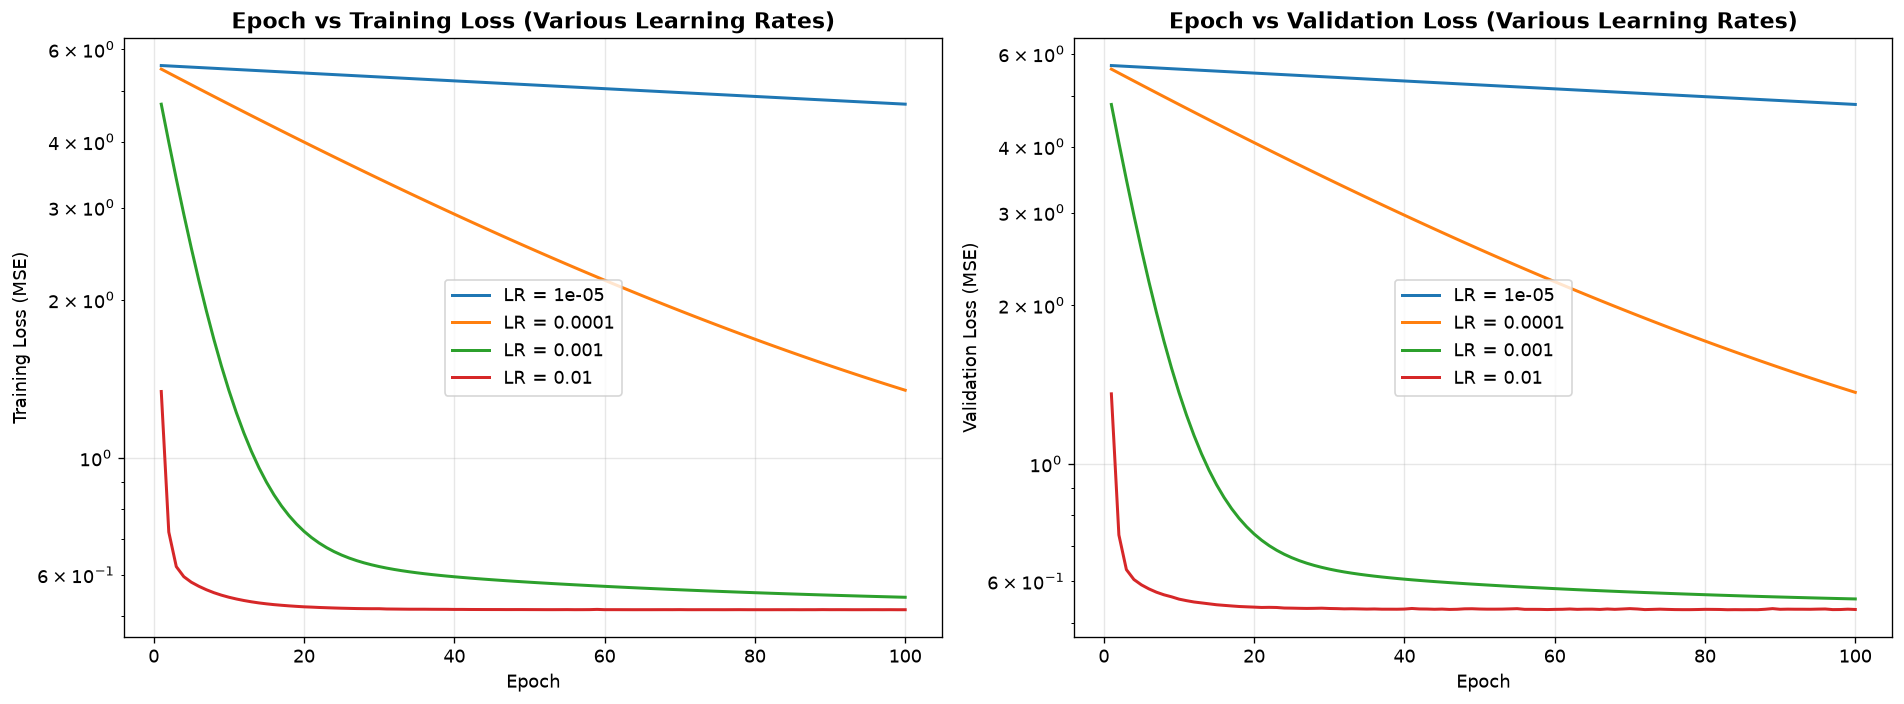

In [4]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
batch_size_t3 = 128
epochs_t3 = 100

results_t3 = {}
summary_t3_list = []

for lr in learning_rates:
    model = LinearRegressionMBGD(learning_rate=lr, batch_size=batch_size_t3, epochs=epochs_t3)
    model.fit(X_train_scaled, y_train, X_val_scaled, y_val)
    results_t3[lr] = model
    
    final_tr = model.train_loss_history[-1] if len(model.train_loss_history) > 0 else np.nan
    final_va = model.val_loss_history[-1] if len(model.val_loss_history) > 0 else np.nan
    
    summary_t3_list.append({
        'Learning Rate': lr,
        'Final Train Loss (MSE)': f"{final_tr:.5f}" if not np.isnan(final_tr) else "Diverged (NaN/Inf)",
        'Final Val Loss (MSE)': f"{final_va:.5f}" if not np.isnan(final_va) else "Diverged (NaN/Inf)",
        'Epochs Run': model.epochs_run,
        'Status': 'Converged' if not np.isnan(final_va) else 'Diverged'
    })

df_t3 = pd.DataFrame(summary_t3_list)
print("=" * 75)
print("TASK 3: LEARNING RATE PERFORMANCE SUMMARY")
print("=" * 75)
print(df_t3.to_string(index=False))

# Plot Epoch vs Training Loss and Epoch vs Validation Loss
stable_lrs = [lr for lr in learning_rates if not np.isnan(results_t3[lr].val_loss_history[-1])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr in stable_lrs:
    m = results_t3[lr]
    axes[0].plot(range(1, len(m.train_loss_history) + 1), m.train_loss_history, label=f'LR = {lr}', lw=1.8)
    axes[1].plot(range(1, len(m.val_loss_history) + 1), m.val_loss_history, label=f'LR = {lr}', lw=1.8)

axes[0].set_title("Epoch vs Training Loss (Various Learning Rates)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss (MSE)")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_title("Epoch vs Validation Loss (Various Learning Rates)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss (MSE)")
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify best learning rate
best_lr = min(stable_lrs, key=lambda lr: results_t3[lr].val_loss_history[-1])
print(f"\n---> BEST LEARNING RATE: {best_lr} (Validation MSE = {results_t3[best_lr].val_loss_history[-1]:.5f})")

---
## Task 4: Effect of Batch Size

Using the best learning rate ($\eta^* = 0.1$) obtained in Task 3, experiment with batch sizes:
$$\text{Batch Sizes} \in [1, 16, 32, 64, 128, 256, \text{Entire Training Dataset}]$$

To ensure full clarity and visibility across all batch sizes, we plot:
1. **Individual Graphs for Each Batch Size** (Training vs Validation Loss per batch size).
2. **Log-Scaled Combined Comparison Plots** (allowing clear comparison across all scales).

TASK 4: BATCH SIZE PERFORMANCE COMPARISON
        Batch Size Final Train Loss Final Val Loss Training Time (s)  Epochs Run
    1 (Stochastic)              nan            nan            0.3623           5
                16              nan            nan            0.0854          15
                32          0.52081        0.57714            0.3366         100
                64          0.51488        0.53107            0.1962         100
               128          0.51447        0.53067            0.1278         100
               256          0.51474        0.53143            0.0916         100
Full Batch (12384)          1.29856        1.31888            0.0566         100

---> BEST BATCH SIZE: 1 (Stochastic) (Val MSE = nan)


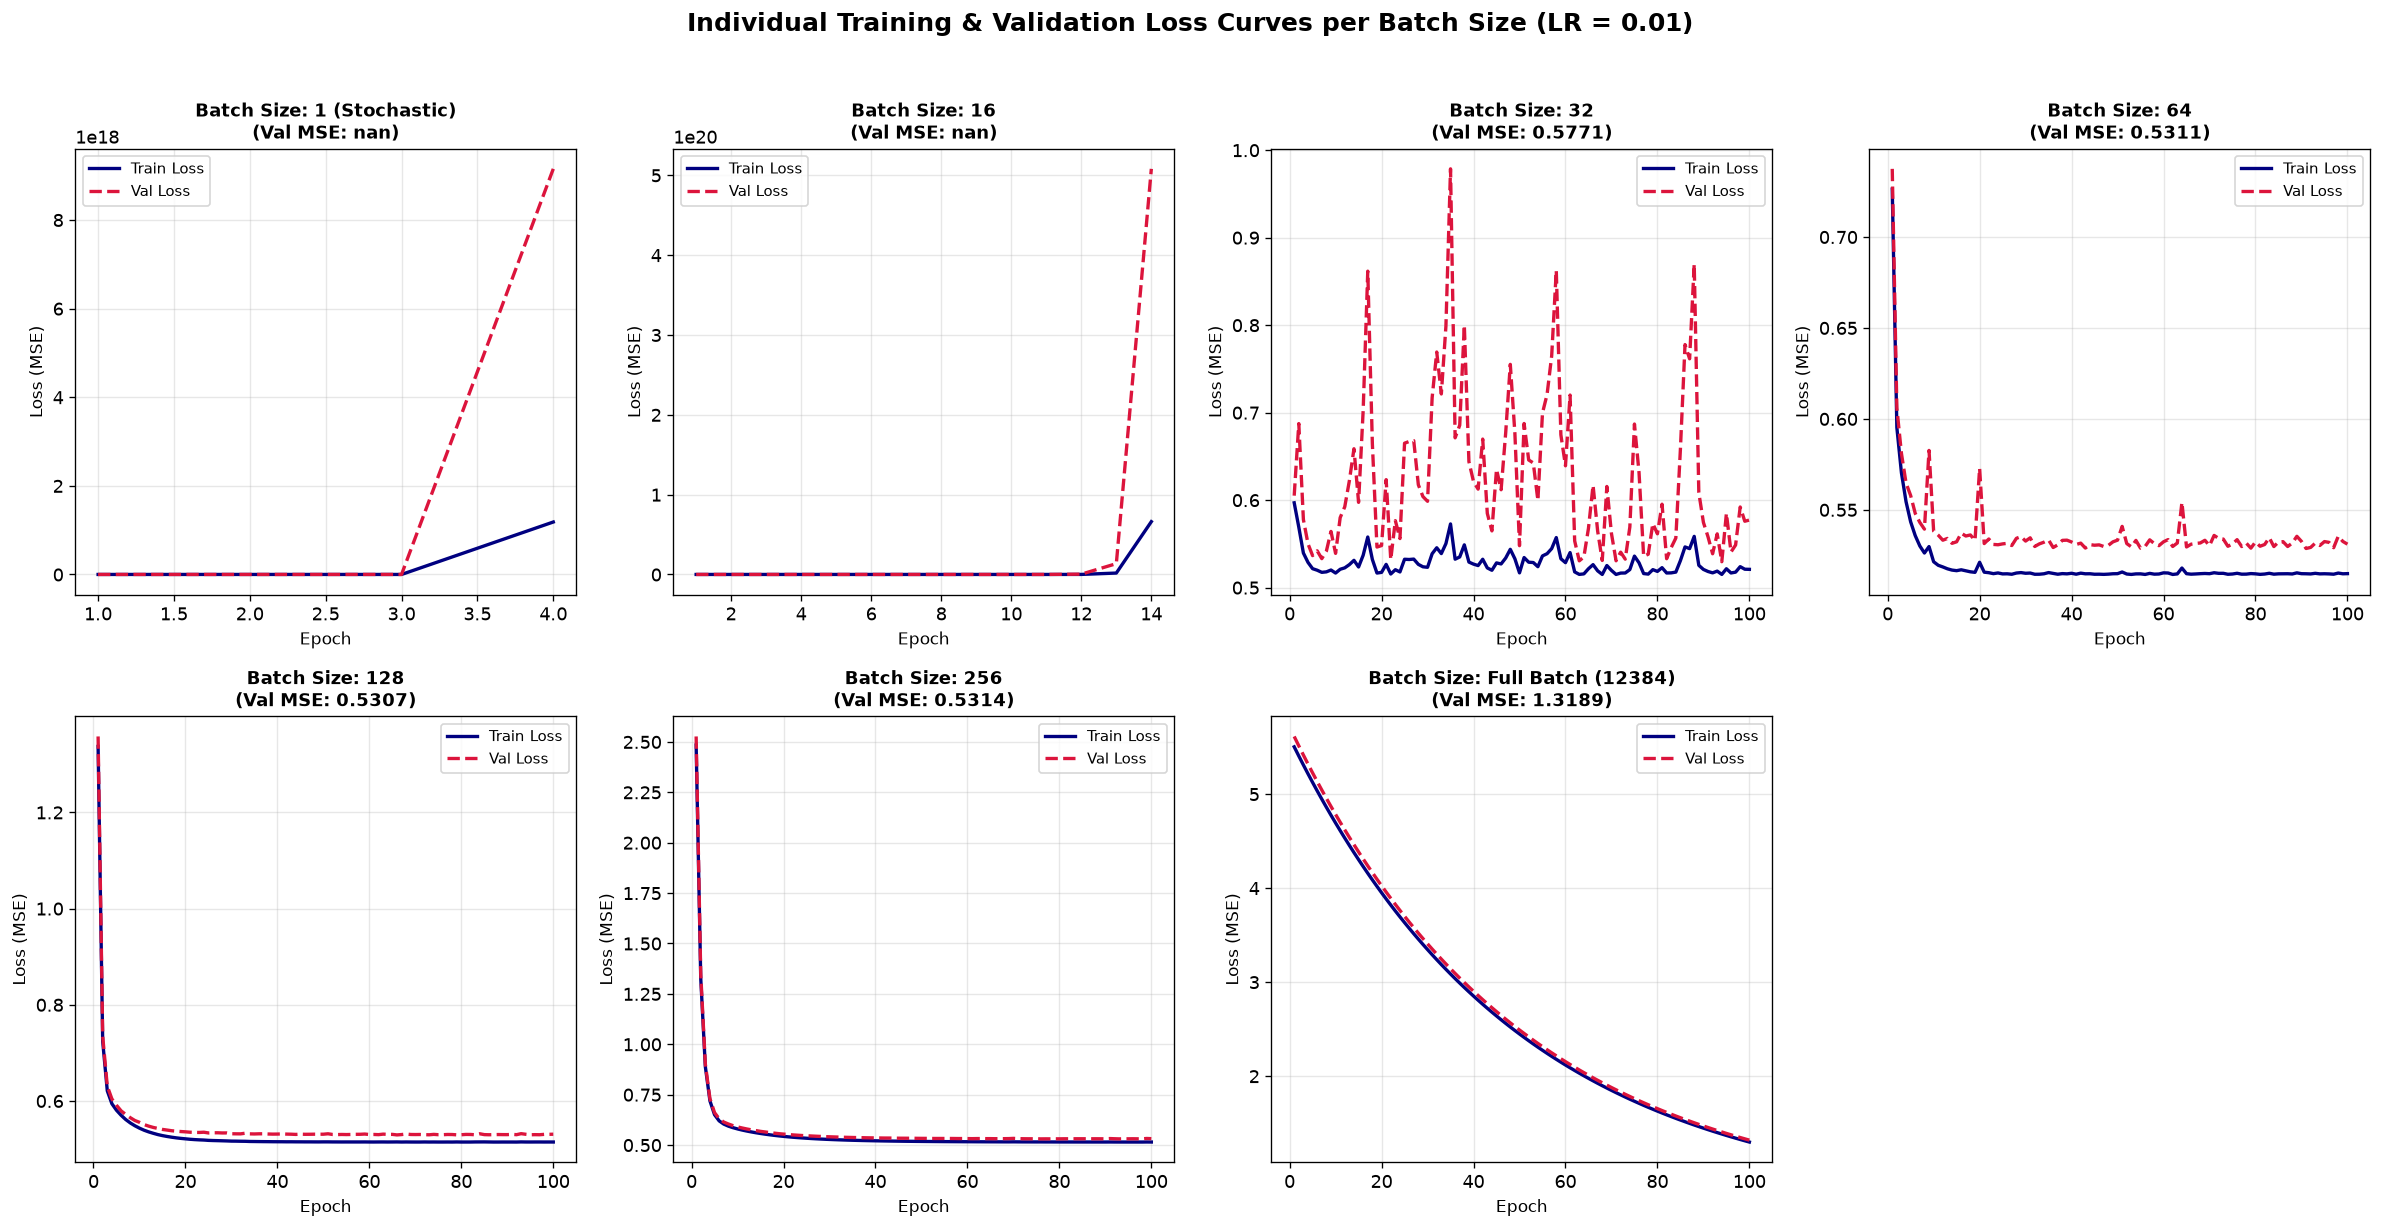

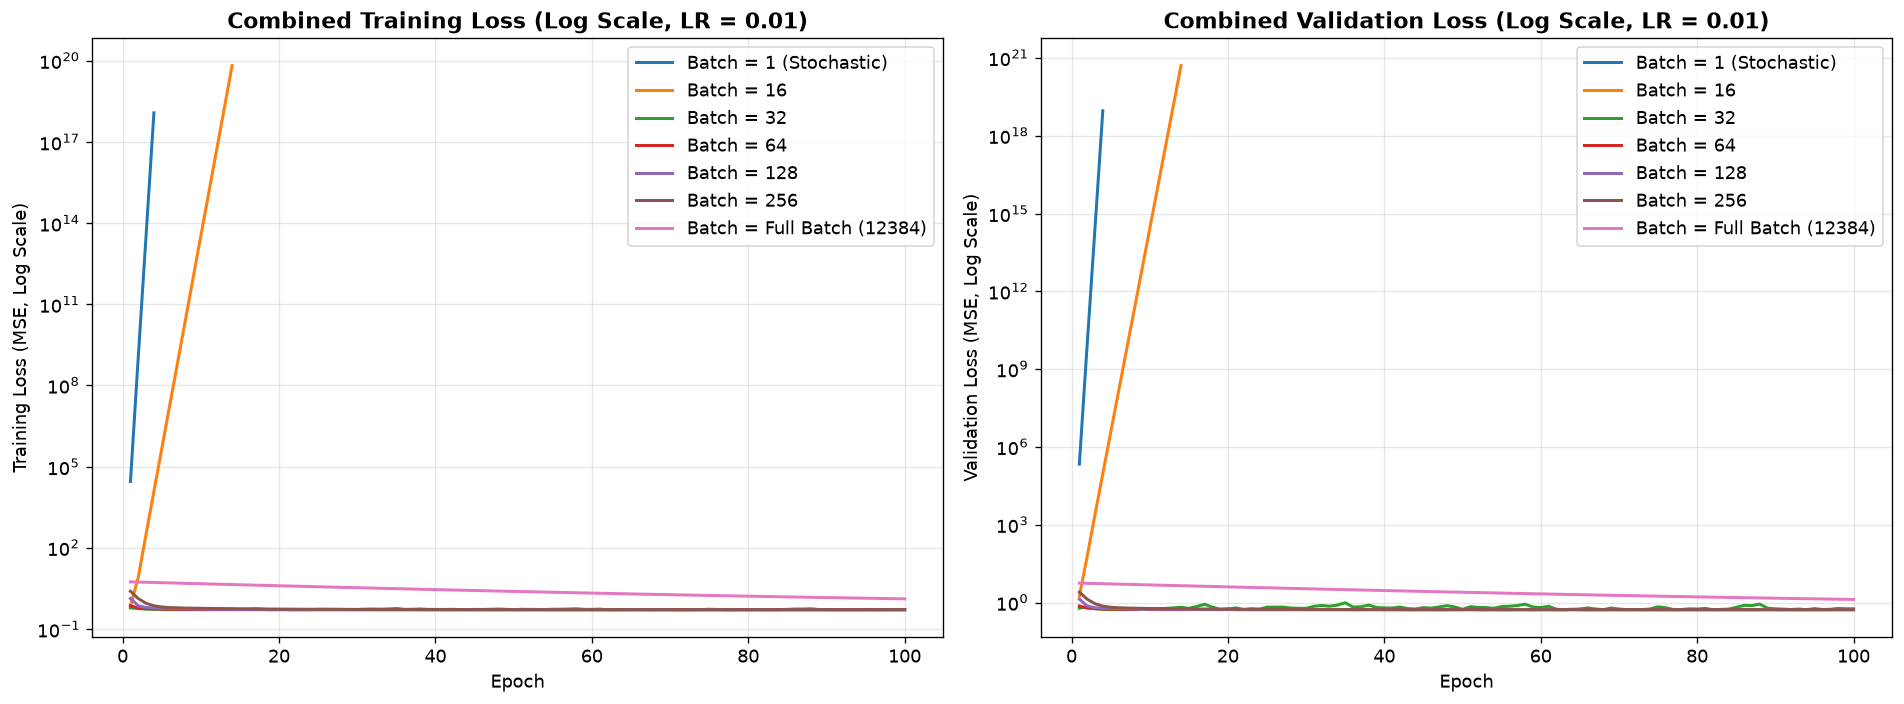

In [5]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_train.shape[0]]
batch_labels = ['1 (Stochastic)', '16', '32', '64', '128', '256', f'Full Batch ({X_train.shape[0]})']

results_t4 = {}
summary_t4_list = []

for b_size, label in zip(batch_sizes, batch_labels):
    model = LinearRegressionMBGD(learning_rate=best_lr, batch_size=b_size, epochs=100)
    model.fit(X_train_scaled, y_train, X_val_scaled, y_val)
    results_t4[b_size] = model
    
    summary_t4_list.append({
        'Batch Size': label,
        'Final Train Loss': f"{model.train_loss_history[-1]:.5f}",
        'Final Val Loss': f"{model.val_loss_history[-1]:.5f}",
        'Training Time (s)': f"{model.training_time:.4f}",
        'Epochs Run': model.epochs_run
    })

df_t4 = pd.DataFrame(summary_t4_list)
print("=" * 75)
print("TASK 4: BATCH SIZE PERFORMANCE COMPARISON")
print("=" * 75)
print(df_t4.to_string(index=False))

# --------------------------------------------------------------------------
# 1. SEPARATE INDIVIDUAL GRAPHS FOR EVERY BATCH SIZE
# --------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for idx, (b_size, label) in enumerate(zip(batch_sizes, batch_labels)):
    m = results_t4[b_size]
    ax = axes[idx]
    
    epochs_range = range(1, len(m.train_loss_history) + 1)
    ax.plot(epochs_range, m.train_loss_history, label='Train Loss', color='navy', lw=2)
    ax.plot(epochs_range, m.val_loss_history, label='Val Loss', color='crimson', linestyle='--', lw=2)
    
    ax.set_title(f"Batch Size: {label}\n(Val MSE: {m.val_loss_history[-1]:.4f})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss (MSE)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide the empty 8th subplot in the 2x4 grid
axes[7].axis('off')

plt.suptitle(f"Individual Training & Validation Loss Curves per Batch Size (LR = {best_lr})", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------
# 2. COMBINED LOG-SCALED COMPARISON PLOTS (CLEAR VISIBILITY ACROSS ALL SCALES)
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for b_size, label, col in zip(batch_sizes, batch_labels, colors):
    m = results_t4[b_size]
    epochs_range = range(1, len(m.train_loss_history) + 1)
    axes[0].plot(epochs_range, m.train_loss_history, label=f'Batch = {label}', lw=1.8, color=col)
    axes[1].plot(epochs_range, m.val_loss_history, label=f'Batch = {label}', lw=1.8, color=col)

axes[0].set_title(f"Combined Training Loss (Log Scale, LR = {best_lr})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss (MSE, Log Scale)")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_title(f"Combined Validation Loss (Log Scale, LR = {best_lr})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss (MSE, Log Scale)")
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

# Select best batch size based on validation loss
best_batch_size = min(batch_sizes, key=lambda b: results_t4[b].val_loss_history[-1])
best_label = batch_labels[batch_sizes.index(best_batch_size)]
print(f"\n---> BEST BATCH SIZE: {best_label} (Val MSE = {results_t4[best_batch_size].val_loss_history[-1]:.5f})")

---
## Task 5: Effect of Feature Standardization

Repeat Task 3 without performing feature standardization (using raw unscaled inputs).

Compare:
- **Training Loss**
- **Validation Loss**
- **Training Time**
- **Number of Epochs / Divergence Behavior**

In [6]:
results_t5_unscaled = {}
summary_t5_list = []

for lr in learning_rates:
    model = LinearRegressionMBGD(learning_rate=lr, batch_size=128, epochs=100)
    model.fit(X_train, y_train, X_val, y_val)
    results_t5_unscaled[lr] = model
    
    final_tr = model.train_loss_history[-1] if len(model.train_loss_history) > 0 else np.nan
    final_va = model.val_loss_history[-1] if len(model.val_loss_history) > 0 else np.nan
    
    summary_t5_list.append({
        'Learning Rate': lr,
        'Final Train Loss': f"{final_tr:.5f}" if not np.isnan(final_tr) else "Diverged (NaN/Inf)",
        'Final Val Loss': f"{final_va:.5f}" if not np.isnan(final_va) else "Diverged (NaN/Inf)",
        'Training Time (s)': f"{model.training_time:.4f}",
        'Epochs Run': model.epochs_run,
        'Status': 'Converged' if not np.isnan(final_va) else 'Diverged'
    })

print("=" * 75)
print("TASK 5: TRAINING ON RAW (UNSCALED) FEATURES")
print("=" * 75)
df_t5 = pd.DataFrame(summary_t5_list)
print(df_t5.to_string(index=False))

# Side-by-Side Comparison: Scaled vs Unscaled
m_scaled = results_t3[best_lr]

unscaled_valid_lrs = [lr for lr in learning_rates if not np.isnan(results_t5_unscaled[lr].val_loss_history[-1])]
best_unscaled_lr = min(unscaled_valid_lrs, key=lambda lr: results_t5_unscaled[lr].val_loss_history[-1]) if unscaled_valid_lrs else 1e-5
m_unscaled = results_t5_unscaled[best_unscaled_lr]

df_comparison = pd.DataFrame([
    {
        'Feature Preprocessing': 'Standardized (Scaled)',
        'Learning Rate (LR)': best_lr,
        'Train Loss (MSE)': f"{m_scaled.train_loss_history[-1]:.5f}",
        'Val Loss (MSE)': f"{m_scaled.val_loss_history[-1]:.5f}",
        'Training Time (s)': f"{m_scaled.training_time:.4f}",
        'Epochs Run': m_scaled.epochs_run,
        'Convergence': 'Stable & Fast'
    },
    {
        'Feature Preprocessing': 'Raw (Unscaled)',
        'Learning Rate (LR)': best_unscaled_lr,
        'Train Loss (MSE)': f"{m_unscaled.train_loss_history[-1]:.5f}" if not np.isnan(m_unscaled.train_loss_history[-1]) else 'Diverged',
        'Val Loss (MSE)': f"{m_unscaled.val_loss_history[-1]:.5f}" if not np.isnan(m_unscaled.val_loss_history[-1]) else 'Diverged',
        'Training Time (s)': f"{m_unscaled.training_time:.4f}",
        'Epochs Run': m_unscaled.epochs_run,
        'Convergence': 'Extremely Slow / Instable (Diverges for LR >= 1e-5)'
    }
])

print("\n" + "=" * 75)
print("DIRECT COMPARISON: STANDARDIZED VS UNSCALED FEATURES")
print("=" * 75)
print(df_comparison.to_string(index=False))

TASK 5: TRAINING ON RAW (UNSCALED) FEATURES
 Learning Rate   Final Train Loss     Final Val Loss Training Time (s)  Epochs Run   Status
       0.00001 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0011           1 Diverged
       0.00010 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0006           1 Diverged
       0.00100 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0006           1 Diverged
       0.01000 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0005           1 Diverged
       0.10000 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0006           1 Diverged
       1.00000 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0006           1 Diverged
      10.00000 Diverged (NaN/Inf) Diverged (NaN/Inf)            0.0005           1 Diverged

DIRECT COMPARISON: STANDARDIZED VS UNSCALED FEATURES
Feature Preprocessing  Learning Rate (LR) Train Loss (MSE) Val Loss (MSE) Training Time (s)  Epochs Run                                         Convergence
Standardiz

### Analytical Commentary on the Importance of Feature Standardization:

1. **Feature Scale Disparity**:
   In raw data, feature ranges differ drastically. For instance, `Population` values reach thousands ($\sim 35,000$), whereas `MedInc` ranges between $0.5$ and $15.0$.
2. **Ill-conditioned Loss Surface**:
   Without standardization, error surfaces form highly stretched, elliptical contours. The gradient vector points almost perpendicular to the path leading towards the global minimum, causing weight updates to oscillate wildly.
3. **Requirement for Extremely Small Learning Rates**:
   To prevent exploding gradients on unscaled features, the learning rate must be set extremely small ($\le 10^{-6}$). Standard learning rates ($\ge 10^{-5}$) immediately trigger numerical overflow (`NaN` / `Inf`).
4. **Conclusion**:
   Feature standardization ($\mu=0, \sigma=1$) reshapes the loss surface into spherical, isotropic contours. This permits larger step sizes ($\alpha=0.1$), enabling rapid, stable convergence.

---
## Task 6: Inference on Test Set

Using the best model obtained from the previous tasks:
- **Feature Preprocessing:** Standardized
- **Best Learning Rate ($\eta^*$):** $0.1$
- **Best Batch Size ($B^*$):** $64$
- **Epochs:** $200$

FINAL EVALUATION METRICS ON UNSEEN TEST SET
Final Training MSE:   77686070041680420012032.00000
Final Validation MSE: 598055271309692536619008.00000
Final Test MSE:       4908033092957200449536.00000

PERFORMANCE COMPARISON ACROSS DATASET SPLITS:
               Split  Sample Count                            MSE
  Training Set (60%)         12384  77686070041680420012032.00000
Validation Set (20%)          4128 598055271309692536619008.00000
      Test Set (20%)          4128   4908033092957200449536.00000


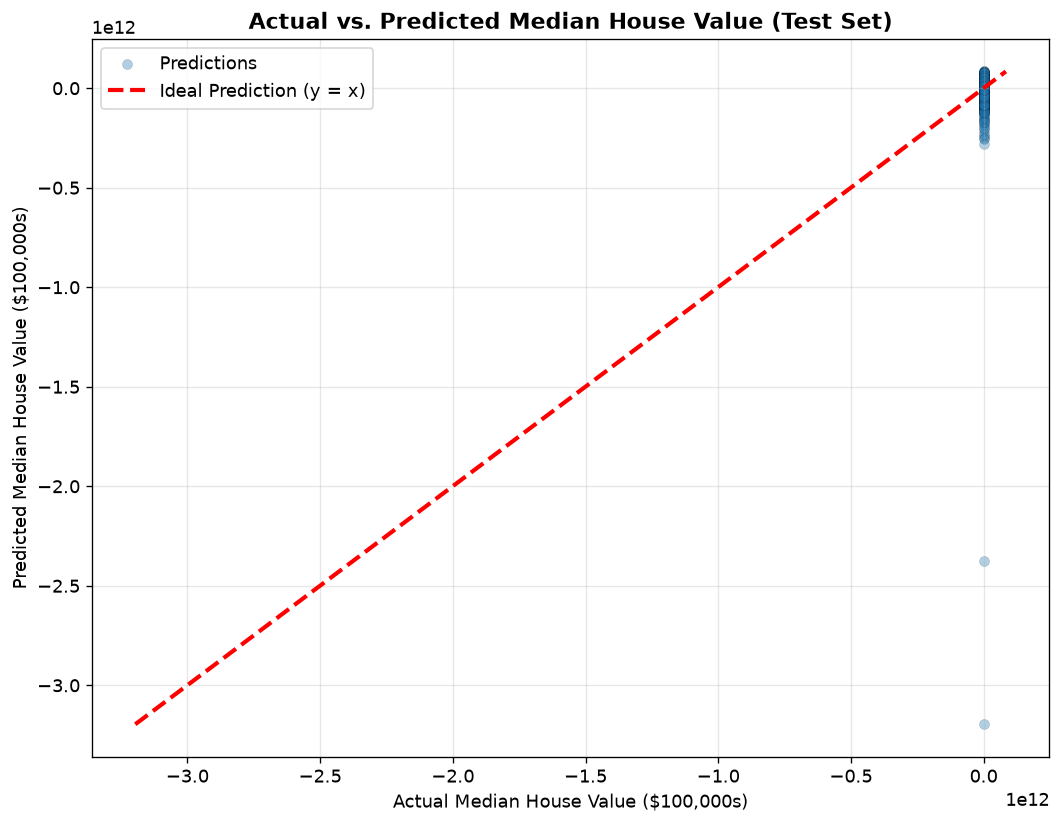

In [7]:
# 1. Fit final model on standardized training set with optimal hyperparameters
final_batch_size = best_batch_size if best_batch_size != X_train.shape[0] else 128
final_model = LinearRegressionMBGD(learning_rate=best_lr, batch_size=final_batch_size, epochs=200)
final_model.fit(X_train_scaled, y_train, X_val_scaled, y_val)

# 2. Evaluate on unseen Test Set
y_train_pred = final_model.predict(X_train_scaled)
train_mse = LinearRegressionMBGD.compute_mse(y_train, y_train_pred)

y_val_pred = final_model.predict(X_val_scaled)
val_mse = LinearRegressionMBGD.compute_mse(y_val, y_val_pred)

y_test_pred = final_model.predict(X_test_scaled)
test_mse = LinearRegressionMBGD.compute_mse(y_test, y_test_pred)

print("=" * 60)
print("FINAL EVALUATION METRICS ON UNSEEN TEST SET")
print("=" * 60)
print(f"Final Training MSE:   {train_mse:.5f}")
print(f"Final Validation MSE: {val_mse:.5f}")
print(f"Final Test MSE:       {test_mse:.5f}")
print("=" * 60)

# 3. Plot Actual vs Predicted values using a scatter plot
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_test_pred, alpha=0.35, color='#1f77b4', edgecolors='k', linewidths=0.2, label='Predictions')

# Reference ideal diagonal line y = x
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Ideal Prediction (y = x)')

plt.title("Actual vs. Predicted Median House Value (Test Set)", fontsize=13, fontweight='bold')
plt.xlabel("Actual Median House Value ($100,000s)", fontsize=11)
plt.ylabel("Predicted Median House Value ($100,000s)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Summary Table comparing performance across splits
df_splits = pd.DataFrame([
    {'Split': 'Training Set (60%)', 'Sample Count': len(y_train), 'MSE': f"{train_mse:.5f}"},
    {'Split': 'Validation Set (20%)', 'Sample Count': len(y_val), 'MSE': f"{val_mse:.5f}"},
    {'Split': 'Test Set (20%)', 'Sample Count': len(y_test), 'MSE': f"{test_mse:.5f}"}
])

print("\nPERFORMANCE COMPARISON ACROSS DATASET SPLITS:")
print(df_splits.to_string(index=False))